# Face Detection with Haar Cascades

**Note: This is face *detection* NOT face *recognition*. We are only detecting if a face is in an image, not who the face actually is. That requires deep learning.**

## 1) Load and Display Images

- Step 1: Import necessary packages: numpy, cv2, matplotlib.pyplot
- Step 2: Load grayscale images using cv2.imread() with flag 0
- Step 3: Display images using plt.imshow() with cmap='gray'

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
# Import necessary packages
with_glass = cv2.imread('withgl.jpg',0)
with_out_glass = cv2.imread('kanagavel .jpg',0)
group_photo = cv2.imread('group.jpg',0)

## Images

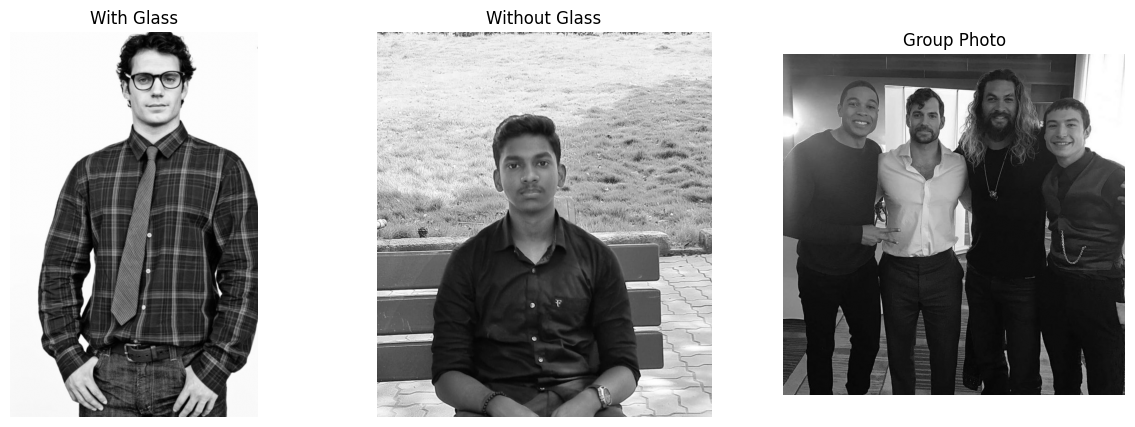

In [4]:
# Display images
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(with_glass,cmap='gray')
plt.title("With Glass")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(with_out_glass,cmap='gray')
plt.title("Without Glass")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(group_photo,cmap='gray')
plt.title("Group Photo")
plt.axis('off')

plt.show()

## II) Load Haar Cascade Classifiers

- Step 1: Load face and eye cascade XML files

## Face Detection

In [5]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

## III) Perform Face Detection in Images

- Step 1: Define a function detect_face() that copies the input image
- Step 2: Use face_cascade.detectMultiScale() to detect faces
- Step 3: Draw white rectangles around detected faces with thickness 10
- Step 4: Return the processed image with rectangles

In [6]:
def detect_face(img):

    # Create a copy of image
    face_img = img.copy()

    # Detect faces
    faces = face_cascade.detectMultiScale(
        face_img,
        scaleFactor=1.1,
        minNeighbors=5
    )

    # Draw rectangles around faces
    for (x,y,w,h) in faces:
        cv2.rectangle(face_img,
                      (x,y),
                      (x+w,y+h),
                      (255,255,255),
                      10)

    return face_img

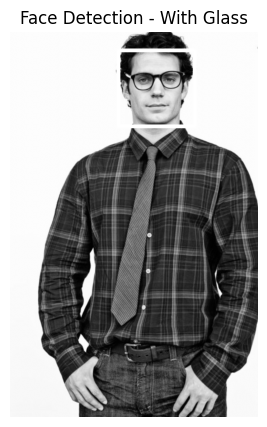

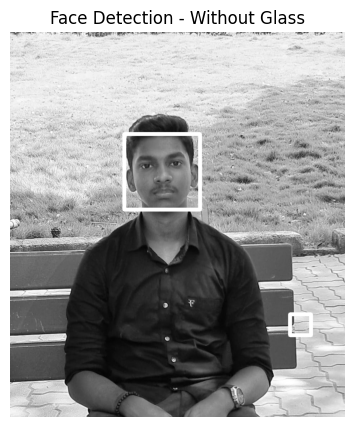

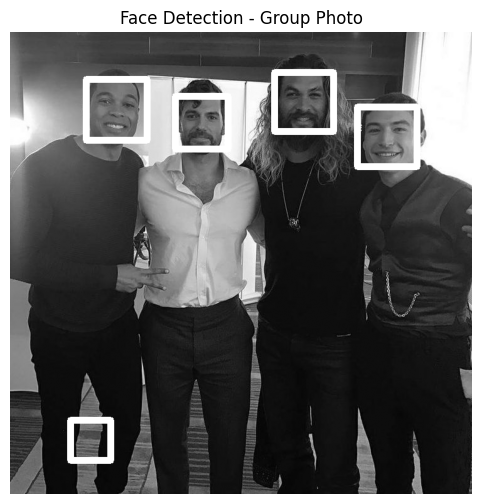

In [7]:
# Detect Face in Images

result = detect_face(with_glass)

plt.figure(figsize=(5,5))
plt.imshow(result,cmap='gray')
plt.title("Face Detection - With Glass")
plt.axis('off')
plt.show()

result = detect_face(with_out_glass)

plt.figure(figsize=(5,5))
plt.imshow(result,cmap='gray')
plt.title("Face Detection - Without Glass")
plt.axis('off')
plt.show()

result = detect_face(group_photo)

plt.figure(figsize=(8,6))
plt.imshow(result,cmap='gray')
plt.title("Face Detection - Group Photo")
plt.axis('off')
plt.show()

In [8]:
# Adjusted Face Detection Function


def adj_detect_face(img):

    face_img = img.copy()

    faces = face_cascade.detectMultiScale(
        face_img,
        scaleFactor=1.05,
        minNeighbors=3
    )

    for (x,y,w,h) in faces:
        cv2.rectangle(face_img,
                      (x,y),
                      (x+w,y+h),
                      (255,255,255),
                      10)

    return face_img

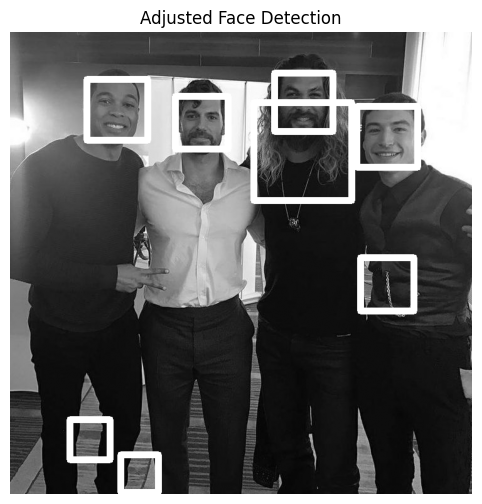

In [9]:
# Detect Side Faces in Group Photo


result = adj_detect_face(group_photo)

plt.figure(figsize=(8,6))
plt.imshow(result,cmap='gray')
plt.title("Adjusted Face Detection")
plt.axis('off')
plt.show()

In [10]:

# Load Eye Cascade Classifier

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_eye.xml'
)

In [11]:
# Eye Detection Function

def detect_eyes(img):

    face_img = img.copy()

    # Detect eyes
    eyes = eye_cascade.detectMultiScale(
        face_img,
        scaleFactor=1.1,
        minNeighbors=5
    )

    # Draw rectangles around eyes
    for (x,y,w,h) in eyes:
        cv2.rectangle(face_img,
                      (x,y),
                      (x+w,y+h),
                      (255,255,255),
                      5)

    return face_img

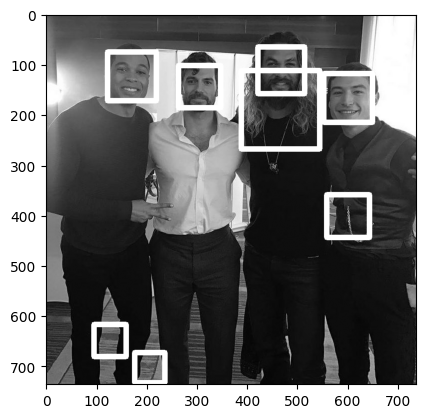

In [12]:
# Doesn't detect the side face.
result = adj_detect_face(group_photo)
plt.imshow(result,cmap='gray')

## IV) Perform Eye Detection in Images & Display Detection Results on Images

- Step 1: Define a function detect_eyes() that copies the input image
- Step 2: Use eye_cascade.detectMultiScale() to detect eyes
- Step 3: Draw white rectangles around detected eyes with thickness 10
- Step 4: Return the processed image with rectangles
- Step 5: Call detect_face() or detect_eyes() on loaded images
- Step 6: Use plt.imshow() with cmap='gray' to display images with detected regions highlighted

In [13]:
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

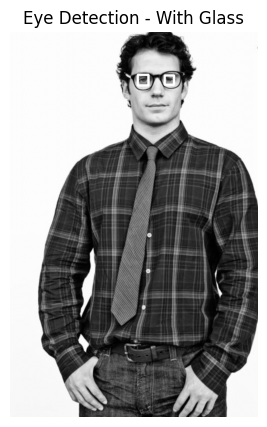

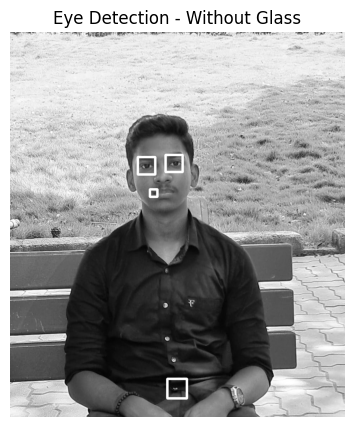

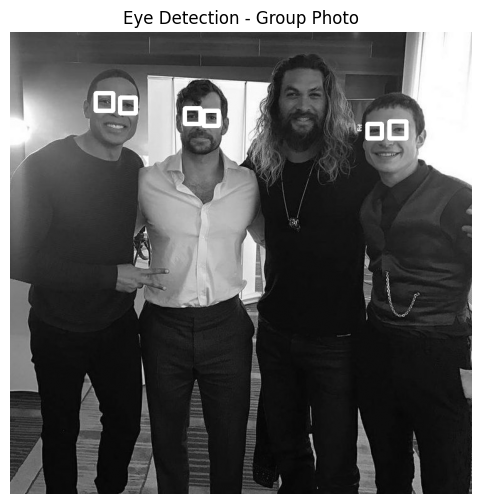

In [14]:
# Detect Eyes in Images

result = detect_eyes(with_glass)

plt.figure(figsize=(5,5))
plt.imshow(result,cmap='gray')
plt.title("Eye Detection - With Glass")
plt.axis('off')
plt.show()

result = detect_eyes(with_out_glass)

plt.figure(figsize=(5,5))
plt.imshow(result,cmap='gray')
plt.title("Eye Detection - Without Glass")
plt.axis('off')
plt.show()

result = detect_eyes(group_photo)

plt.figure(figsize=(8,6))
plt.imshow(result,cmap='gray')
plt.title("Eye Detection - Group Photo")
plt.axis('off')
plt.show()

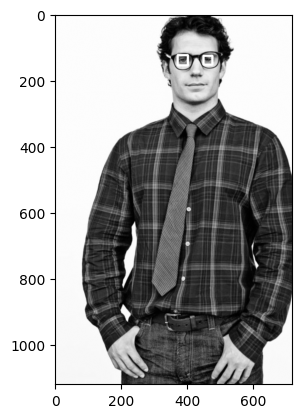

In [15]:
result = detect_eyes(with_glass)
plt.imshow(result,cmap='gray')

In [16]:
eyes = eye_cascade.detectMultiScale(with_out_glass) 

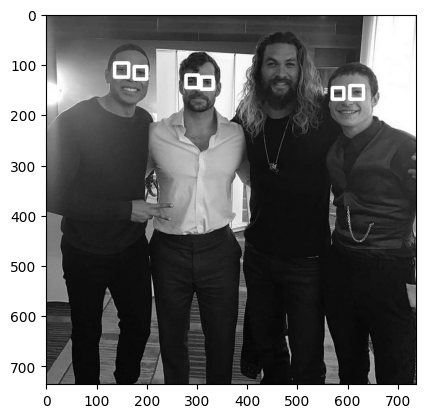

In [17]:
# White around the pupils is not distinct enough to detect eyes here!
result = detect_eyes(group_photo)
plt.imshow(result,cmap='gray')

## VI) Perform Face Detection on Real-Time Webcam Video

- Step 1: Capture video from webcam using cv2.VideoCapture(0)
- Step 2: Loop to continuously read frames from webcam
- Step 3: Apply detect_face() function on each frame
- Step 4: Display the video frame with rectangles around detected faces
- Step 5: Exit loop and close windows when ESC key (key code 27) is pressed
- Step 6: Release video capture and destroy all OpenCV windows

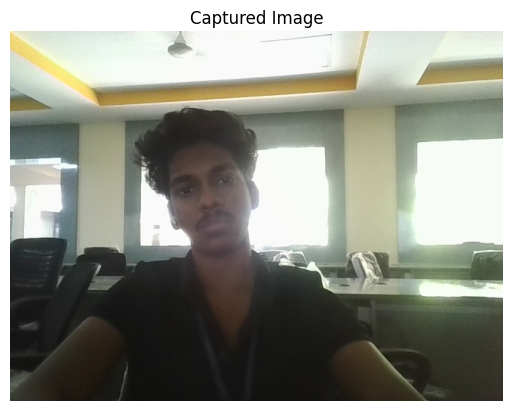

In [22]:
import cv2
import time
import matplotlib.pyplot as plt

face_cascade = cv2.CascadeClassifier(
    'haarcascade_frontalface_default.xml'
)

cap = cv2.VideoCapture(0)

start = time.time()

while True:

    ret, frame = cap.read()

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.1, 5)

    for (x, y, w, h) in faces:

        cv2.rectangle(frame, (x, y), (x+w, y+h), (0,255,0), 2)

    cv2.imshow("Face Detection", frame)

    if time.time() - start >= 5:

        cv2.imwrite("output.jpg", frame)

        break

    if cv2.waitKey(1) == 27:
        break

cap.release()

cv2.destroyAllWindows()

image = cv2.imread("output.jpg")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)

plt.title("Captured Image")

plt.axis('off')

plt.show()